In [37]:
import numpy as np
import pandas as pd
import warnings
from sklearn.exceptions import DataConversionWarning
from sklearn.preprocessing import RobustScaler
from dowhy import CausalModel
import graphviz
from IPython.display import display
import importlib, tests
importlib.reload(tests)


warnings.filterwarnings("ignore", category=DataConversionWarning)

In [38]:
df = pd.read_csv("alerts_with_category_and_apk_size_updated_cryptoguard.csv")
df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()

df["verdict"] = df["verdict"].astype(int)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)

download_order = [
    "<100","100-500","500-1k","1k-5k","5k-10k","10k-50k",
    "50k-100k","100k-500k","500k-1M","1M-5M",">5M"
]
ord_map = {c:i for i,c in enumerate(download_order)}
df["app_popularity_encoded"] = df["apk_category"].map(ord_map)
df = df.dropna(subset=["app_popularity_encoded"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

print("Rows:", len(df))
print("Popularity counts:\n", df["apk_category"].value_counts().reindex(download_order, fill_value=0))
print("is_third_party counts:\n", df["is_third_party"].value_counts())


Rows: 15268
Popularity counts:
 apk_category
<100         1791
100-500      1373
500-1k       1290
1k-5k        1310
5k-10k       1162
10k-50k      1122
50k-100k     1103
100k-500k    1889
500k-1M      1810
1M-5M        1115
>5M          1303
Name: count, dtype: int64
is_third_party counts:
 is_third_party
1    13943
0     1325
Name: count, dtype: int64


In [39]:
refutation_methods = [
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter",
]

baseline_bucket = "<100"
baseline_code = ord_map[baseline_bucket]

results = []


In [40]:
def balance_bucket_pair_bootstrap(df_sub, bucket_col, baseline_code, treated_code,  random_state=42):
    base = df_sub[df_sub[bucket_col] == baseline_code]
    trt  = df_sub[df_sub[bucket_col] == treated_code]

    n_base = len(base)
    n_trt  = len(trt)

    base_bal = base.copy()

    if n_trt >= n_base:
        trt_bal = trt.sample(n=n_base, replace=False, random_state=random_state)
    else:
        trt_bal = trt.sample(n=n_base, replace=True,  random_state=random_state)

    out = pd.concat([base_bal, trt_bal], axis=0)
    out = out.sample(frac=1, random_state=random_state).reset_index(drop=True)


    return out


In [41]:

# APK size and is_third_party as confounders
def generate_causal_graph():
    causal_graph = """
    digraph {
        combined -> verdict;
        is_third_party -> combined;
        is_third_party -> verdict;
        apk_size_scaled -> combined;
        apk_size_scaled -> verdict;
        is_third_party -> apk_size_scaled;
    }
    """

    return causal_graph


# APK size and is_third_party as confounders
def estimate_causal_effect(df_sub, causal_graph):
    model = CausalModel(
        data=df_sub,
        treatment="combined",
        outcome="verdict",
        graph=causal_graph.replace("\n", " "),
        common_causes=["is_third_party", "apk_size_scaled"]
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_matching",
        target_units="ate",
        confidence_intervals='bootstrap',
        method_params={
            "num_simulations": 300,
            "sample_size_fraction": 1.0,
            "confidence_level": 0.95,
        },
    )
    
    return model,identified_estimand,estimate


    
# # APK size is not a confounder, only is_third_party is a confounder
# def generate_causal_graph():
#     causal_graph = """
#     digraph {
#         combined -> verdict;
#         is_third_party -> combined;
#         is_third_party -> verdict;
#         apk_size_scaled -> combined;
#         is_third_party -> apk_size_scaled;
#     }
#     """

#     return causal_graph


# # APK size is not a confounder, only is_third_party is a confounder
# def estimate_causal_effect(df_sub, causal_graph):
#     model = CausalModel(
#         data=df_sub,
#         treatment="combined",
#         outcome="verdict",
#         graph=causal_graph.replace("\n", " "),
#         common_causes=["is_third_party"]
#     )

#     identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

#     estimate = model.estimate_effect(
#         identified_estimand,
#         method_name="backdoor.propensity_score_matching",
#         target_units="ate",
#         confidence_intervals='bootstrap',
#         method_params={
#             "num_simulations": 300,
#             "sample_size_fraction": 1.0,
#             "confidence_level": 0.95,
#         },
#     )
    
#     return model,identified_estimand,estimate


In [42]:
from dowhy import CausalModel
import dowhy.causal_estimators.linear_regression_estimator as lin

def mediation_graph():
    return """
    digraph {
        combined -> apk_size_scaled;
        combined -> verdict;
        apk_size_scaled -> verdict;
        is_third_party -> apk_size_scaled;
        is_third_party -> combined;
        is_third_party -> verdict;
    }
    """

def estimate_nde_nie(df_sub):
    model = CausalModel(
        data=df_sub,
        treatment="combined",
        outcome="verdict",
        graph=mediation_graph().replace("\n", " "),
        missing_nodes_as_confounders=True
    )

    
    estimand_nde = model.identify_effect(estimand_type="nonparametric-nde",
                                        proceed_when_unidentifiable=True)
    estimand_nie = model.identify_effect(estimand_type="nonparametric-nie",
                                        proceed_when_unidentifiable=True)

    nde = model.estimate_effect(
        estimand_nde,
        method_name="mediation.two_stage_regression",
        method_params={
            "first_stage_model": lin.LinearRegressionEstimator,
            "second_stage_model": lin.LinearRegressionEstimator,
        }
    )
    nie = model.estimate_effect(
        estimand_nie,
        method_name="mediation.two_stage_regression",
        method_params={
            "first_stage_model": lin.LinearRegressionEstimator,
            "second_stage_model": lin.LinearRegressionEstimator,
        }
    )

    # print("NDE:", nde.value)
    # print("NIE:", nie.value)
    return nde, nie


/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur


------------ 100-500 vs <100 ------------
Counts: {1: 3582, 0: 1791}
NDE: 0.012840397215754541  || NIE: -0.012840397960144313


combined -> verdict (Spearman)
rho = 0.0358, p = 0.0087
Estimated ATE: 0.028289596128792102
95% CI: (np.float64(-0.08914945095849619), np.float64(0.18462683789316953))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:0.028289596128792102
New effect:0.028289596128792113
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:0.028289596128792102
New effect:-2.5125628140703694e-05
p value:0.98


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:0.028289596128792102
New effect:0.017062587249883666
p value:0.97



/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur


------------ 500-1k vs <100 ------------
Counts: {1: 3582, 0: 1791}
NDE: 0.009213599595917827  || NIE: -0.009213607484335912


combined -> verdict (Spearman)
rho = 0.0348, p = 0.0108
Estimated ATE: -0.10720268006700168
95% CI: (np.float64(-0.384142936906756), np.float64(-0.08728829331844407))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.10720268006700168
New effect:-0.10720268006700161
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.10720268006700168
New effect:-0.002592592592592592
p value:0.98


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.10720268006700168
New effect:0.02412052117263844
p value:0.1299999999999999



/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur

...


------------ 500k-1M vs <100 ------------
Counts: {1: 3582, 0: 1791}
NDE: 0.012411359453411305  || NIE: -0.012411364697961266


combined -> verdict (Spearman)
rho = 0.0516, p = 0.0002
Estimated ATE: 0.10552763819095477
95% CI: (np.float64(0.03070910106085986), np.float64(0.3545505304299274))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:0.10552763819095477
New effect:0.10552763819095475
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:0.10552763819095477
New effect:-0.0001405174018239347
p value:1.0


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:0.10552763819095477
New effect:0.03649371800837599
p value:0.46



/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur


------------ 1M-5M vs <100 ------------
Counts: {1: 3582, 0: 1791}
NDE: 0.01247638263878921  || NIE: -0.012476378269502444


combined -> verdict (Spearman)
rho = 0.0252, p = 0.0642
Estimated ATE: -0.012655871952354365
95% CI: (np.float64(-0.18760469011725295), np.float64(0.15726782058440347))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.012655871952354365
New effect:-0.012655871952354368
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.012655871952354365
New effect:0.0025656058068118364
p value:0.8899999999999999


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.012655871952354365
New effect:0.00726966030711959
p value:0.7



/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/akram/android/akram/ci4sec/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a futur


------------ >5M vs <100 ------------
Counts: {1: 3582, 0: 1791}
NDE: 0.011307450352158466  || NIE: -0.011307450429899613


combined -> verdict (Spearman)
rho = 0.0361, p = 0.0082
Estimated ATE: -0.016005955704448165
95% CI: (np.float64(-0.19653824678950305), np.float64(0.08896333519449097))

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.016005955704448165
New effect:-0.01600595570444816
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.016005955704448165
New effect:-0.003077424157826168
p value:0.935


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.016005955704448165
New effect:0.032316193578408564
p value:0.51



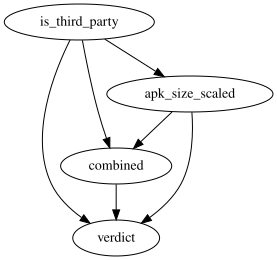

In [43]:
for bucket in download_order:
    if bucket == baseline_bucket:
        continue

    k = ord_map[bucket]

    df_sub = df[df["app_popularity_encoded"].isin([baseline_code, k])].copy()
    df_sub = balance_bucket_pair_bootstrap( df_sub,"app_popularity_encoded", baseline_code, k, random_state=100)

    df_sub["treatment_app_popularity_bucket"] = (df_sub["app_popularity_encoded"] == k).astype(int)
    

    df_all = df_sub.copy()
    df_all["combined"] = 1
    df_baseline = df_sub[df_sub["treatment_app_popularity_bucket"] == 0].copy()
    df_baseline["combined"] = 0
    df_final = pd.concat([df_all, df_baseline], ignore_index=True)
    df_sub = df_final.copy()

    nde, nie = estimate_nde_nie(df_sub)
    
    print("\n" + "-"*12 + f" {bucket} vs {baseline_bucket} " + "-"*12)
    print("Counts:", df_sub["combined"].value_counts().to_dict())
    print("NDE:", nde.value, " || NIE:", nie.value)
    tests.correlation_test_treatment_to_outcome(df_sub)


    causal_graph = generate_causal_graph()

    model, identified_estimand, estimate = estimate_causal_effect(df_sub, causal_graph)

    print("Estimated ATE:", estimate.value)
    try:
        print("95% CI:", estimate.get_confidence_intervals())
    except Exception:
        pass

    results.append({
        "bucket": bucket,
        "ATE_vs_<100": float(estimate.value)
    })

    for method in refutation_methods:
        if method == "placebo_treatment_refuter":
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method,
                placebo_type="permute",
                num_simulations=200
            )
        elif method == "data_subset_refuter":
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method,
                subset_fraction=0.8,
                num_simulations=200
            )
        else:
            ref = model.refute_estimate(
                identified_estimand, estimate,
                method_name=method
            )
        print(f"\nRefuter: {method}\n", ref)

g = graphviz.Source(causal_graph)
display(g)

In [44]:
results_df = pd.DataFrame(results)
print("\n\n","-"*25 + "Summary: Bucket-specific ATE vs <100" + "-"*25)
print(results_df)




 -------------------------Summary: Bucket-specific ATE vs <100-------------------------
      bucket  ATE_vs_<100
0    100-500     0.028290
1     500-1k    -0.107203
2      1k-5k    -0.143681
3     5k-10k     0.010236
4    10k-50k     0.092872
5   50k-100k    -0.008003
6  100k-500k     0.111669
7    500k-1M     0.105528
8      1M-5M    -0.012656
9        >5M    -0.016006
